# Synthetic magnetic diagnostics for CUTE

You cannot see inside a tokamak. Everything we know about the plasma's shape
and current comes from magnetic sensors outside the vessel. Equilibrium
reconstruction works backwards from those readings to figure out what the
plasma was doing.

To do that, you first need to know what the sensors *would* read for a given
plasma. That is what this notebook computes:

$$\text{equilibrium} \longrightarrow \text{sensor readings}$$

There are two sensor types:

- **Flux loops** are wire loops that go around the machine at a fixed $(R, Z)$.
  They measure the poloidal flux $\psi$ at that point.
- **Mirnov probes** are small coils that measure the local magnetic field along
  whichever direction they point, so a probe at angle $\theta$ reads
  $B_R\cos\theta + B_Z\sin\theta$.

The other CUTE examples (`CUTE_mesh_ex`, `CUTE_null_ex`, `CUTE_pulse_ex`) stop
before this step, and `ITER_reconstruction_ex` reconstructs using shape
constraints rather than sensor signals. Simulating the sensors is what lets you
study measurement noise and sensor failures, and what makes it possible to
train a machine learning surrogate later.

CUTE is not running yet, so there is no real data. That is the reason to build
this now: you can design the diagnostic set and test the reconstruction before
the hardware exists.

## Setup

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, create_power_flux_fun

from src.forward.model import full_diagnostic_set
from src.forward.sensors import generate_cute_sensors

Load the CUTE mesh, same as in `CUTE_mesh_ex`. It contains the vacuum vessel,
the 14 CS and 14 PF coils, and the region tags TokaMaker needs.

In [2]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(
    os.path.join(REPO_ROOT, "data", "CUTE_mesh.h5")
)
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

mygs.settings.lim_zmax = 0.38
mygs.settings.pm = False
mygs.setup(order=2, F0=0.17)

# CUTE coils are limited to 1 kA per turn
mygs.set_coil_bounds({key: [-1.0e3, 1.0e3] for key in mygs.coil_sets})
print(len(mygs.coil_sets), "coil sets")

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           b19540a
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/dp/643386y10pg0wlcjl4xc3s7m0000gp/T/oft_75728/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.301E+00
    # of points  =    5796
    # of edges   =   17283
    # of cells   =   11488
    # of boundary points =     102
    # of boundary edges  =     102
    # of boundary cells  =     102
  Resolution statistics:
    hmin =  3.994E-03
    hrms =  1.721E-02
    hmax =  7.410E-02
  Surface grounded at vertex     761


**** Creati

28 coil sets


## A plasma to measure

Solve one equilibrium in the middle of CUTE's range: $I_p = 100$ kA,
$R_0 = 0.32$ m, $a = 0.17$ m, $\kappa = 1.7$, $\delta = 0.4$. Nothing below
depends on this particular choice.

In [3]:
mygs.set_profiles(ffp_prof=create_power_flux_fun(40, 1.5, 2.0),
                  pp_prof=create_power_flux_fun(40, 4.0, 1.0))

R0, Z0, a, kappa, delta = 0.32, 0.0, 0.17, 1.7, 0.4

isoflux_pts = create_isoflux(80, R0, Z0, a, kappa, delta)
isoflux_pts = isoflux_pts[isoflux_pts[:, 0] > 0.3, :]
isoflux_pts = np.vstack((isoflux_pts, np.array([[0.15, 0.0]])))
x_points = np.array([[0.22, -0.33], [0.20, 0.34]])

mygs.set_saddles(x_points)
mygs.set_isoflux(np.vstack((isoflux_pts, x_points)))
mygs.set_targets(Ip=1.0e5, Ip_ratio=4.0)
mygs.init_psi(R0, Z0, 0.13, kappa, delta)
mygs.solve()

stats = mygs.get_stats()
print("Ip    =", round(stats["Ip"] / 1e3, 1), "kA")
print("R_geo =", round(stats["R_geo"], 4), "m")
print("a_geo =", round(stats["a_geo"], 4), "m")
print("q_95  =", round(stats["q_95"], 2))

Ip    = 100.0 kA
R_geo = 0.3156 m
a_geo = 0.1744 m
q_95  = 8.17


## The sensors

56 flux loops and 74 Mirnov probes, 130 channels total.

**Important caveat:** this layout is my own guess at what a machine like CUTE
would carry. It is not the real diagnostic set. Every number later in this
notebook depends on it, so swapping in the actual sensor geometry would be the
most useful change anyone could make here.

flux loops: 56
Mirnov probes: 74
total: 130


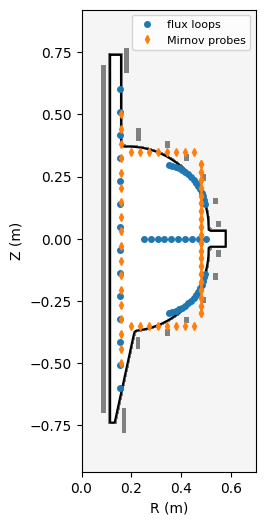

In [4]:
sensors = generate_cute_sensors()
print("flux loops:", sensors.n_flux_loops)
print("Mirnov probes:", sensors.n_mirnov_probes)
print("total:", sensors.n_total)

fl_R = [s["R"] for s in sensors.flux_loops]
fl_Z = [s["Z"] for s in sensors.flux_loops]
mp_R = [s["R"] for s in sensors.mirnov_probes]
mp_Z = [s["Z"] for s in sensors.mirnov_probes]

fig, ax = plt.subplots(figsize=(5, 6))
mygs.plot_machine(fig, ax, coil_colormap=None, limiter_color="k")
ax.plot(fl_R, fl_Z, "o", ms=4, label="flux loops")
ax.plot(mp_R, mp_Z, "d", ms=4, label="Mirnov probes")
ax.set_xlabel("R (m)")
ax.set_ylabel("Z (m)")
ax.legend(fontsize=8)
plt.show()

## Computing the signals

Evaluate $\psi$ at each flux loop and the field component at each Mirnov probe.
One equilibrium goes in, 130 numbers come out.

In [5]:
frame = full_diagnostic_set(mygs, sensors)
channels = [c for c in frame.columns if c != "time"]
signals = frame[channels].to_numpy(dtype=float)[0]

is_loop = np.array([c.startswith("FL_") for c in channels])

print(len(signals), "channels")
print("flux loops (Wb):", signals[is_loop].min(), "to", signals[is_loop].max())
print("Mirnov (T):", signals[~is_loop].min(), "to", signals[~is_loop].max())

130 channels
flux loops (Wb): -0.003204124348837278 to 0.009562431712035569
Mirnov (T): -0.15717768578585153 to 0.17749287198566152


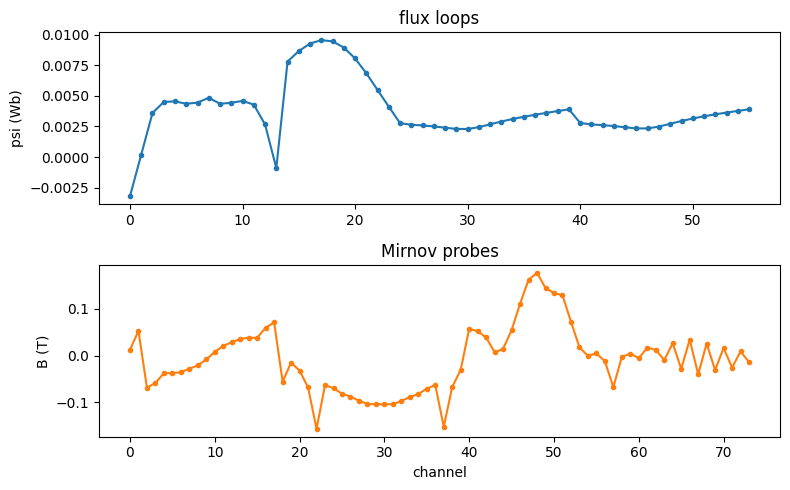

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
ax[0].plot(signals[is_loop], ".-")
ax[0].set_ylabel("psi (Wb)")
ax[0].set_title("flux loops")
ax[1].plot(signals[~is_loop], ".-", color="C1")
ax[1].set_ylabel("B (T)")
ax[1].set_xlabel("channel")
ax[1].set_title("Mirnov probes")
plt.tight_layout()
plt.show()

## Do the signals actually respond to the plasma?

If a sensor barely changes when the plasma changes, it tells you nothing about
it. Worth checking before trusting any of this. Solve at a few different plasma
currents and see how the signals move.

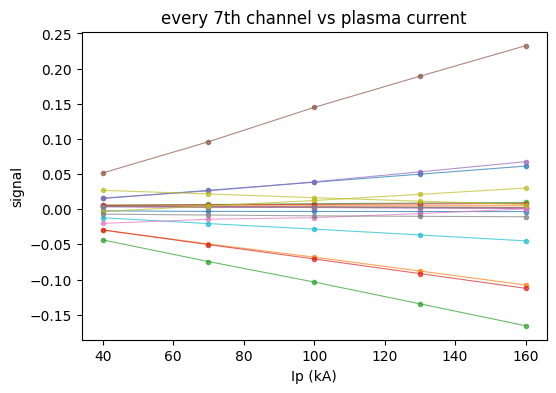

median response: 1.13
channels changing by less than 1%: 0


In [7]:
ip_scan = [4.0e4, 7.0e4, 1.0e5, 1.3e5, 1.6e5]
scan = []

for ip in ip_scan:
    mygs.set_targets(Ip=ip, Ip_ratio=4.0)
    mygs.init_psi(R0, Z0, 0.13, kappa, delta)
    mygs.solve()
    f = full_diagnostic_set(mygs, sensors)
    scan.append(f[channels].to_numpy(dtype=float)[0])

scan = np.array(scan)

fig, ax = plt.subplots(figsize=(6, 4))
for j in range(0, 130, 7):
    ax.plot(np.array(ip_scan) / 1e3, scan[:, j], ".-", lw=0.8, alpha=0.7)
ax.set_xlabel("Ip (kA)")
ax.set_ylabel("signal")
ax.set_title("every 7th channel vs plasma current")
plt.show()

# how much does each channel move across the scan, relative to its own size?
response = np.ptp(scan, axis=0) / (np.abs(scan).mean(axis=0) + 1e-12)
print("median response:", round(float(np.median(response)), 2))
print("channels changing by less than 1%:", int((response < 0.01).sum()))

## Measurement noise

Real sensors are not exact. The simplest model is Gaussian noise on each
channel, scaled to that channel's own size:

$$\tilde{s}_i = s_i + \epsilon_i, \qquad \epsilon_i \sim \mathcal{N}(0, (0.02\,|s_i|)^2)$$

**Important caveat:** I made this noise model up. Real magnetic diagnostics
usually have noise that is correlated between nearby channels, drifts through a
shot because the signals are integrated, and sometimes has large spikes. None
of that is independent Gaussian noise.

So anything validated using this notebook is validated *under this assumption*,
including any error bars. Replacing it with measured noise statistics is one of
the first things to do once CUTE produces data.

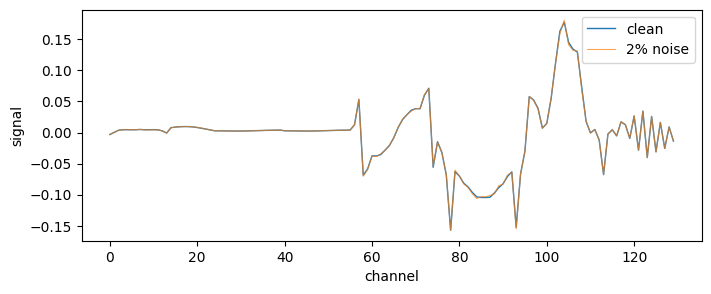

median SNR: 64.7
channels with SNR below 1: 0


In [8]:
rng = np.random.default_rng(0)

clean = scan[2]  # the Ip = 100 kA case
noise = rng.normal(0.0, 1.0, clean.shape) * 0.02 * np.abs(clean)
noisy = clean + noise

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(clean, lw=1, label="clean")
ax.plot(noisy, lw=0.8, alpha=0.7, label="2% noise")
ax.set_xlabel("channel")
ax.set_ylabel("signal")
ax.legend()
plt.show()

# is the noise small compared to how much the signals move between plasmas?
variation = np.ptp(scan, axis=0)
snr = variation / np.maximum(np.abs(noise), 1e-18)
print("median SNR:", round(float(np.median(snr)), 1))
print("channels with SNR below 1:", int((snr < 1).sum()))

## Sensor failures

Probes die, cables come loose, integrators saturate. A reconstruction meant for
real use has to cope with missing channels, so the forward model needs to be
able to represent that too. Here it just means zeroing some of them.

The point is that any accuracy claim should come with a dropout fraction
attached, rather than assuming all 130 channels always work.

In [9]:
for fraction in [0.0, 0.1, 0.2]:
    keep = rng.random(noisy.shape) >= fraction
    degraded = noisy * keep
    print(f"{fraction:.0%} dropout: {int((~keep).sum())} channels lost")

0% dropout: 0 channels lost
10% dropout: 12 channels lost
20% dropout: 22 channels lost


## What this model leaves out

Worth being clear about, since everything built on top inherits these.

Included: the plasma current from a converged free-boundary Grad-Shafranov
solve, the real CUTE vessel and coil geometry, and exact evaluation of $\psi$
and $B$ at each sensor.

Not included:

- **Integrator drift.** Flux measurements are integrated from voltage, so error
  builds up through a shot. A single time slice cannot show this.
- **Pickup from the coils.** Changing coil currents induce signals that have
  nothing to do with the plasma.
- **Calibration error.** Gains and offsets are imperfectly known, which gives
  systematic rather than random error.
- Probes treated as points, and everything axisymmetric.

## Next steps

With the forward map working, the rest follows:

1. Solve many equilibria, compute the sensor signals for each, and save them
   with the plasma parameters as labels. `scripts/generate_gs_dataset.py` does
   this, at roughly 0.26 s per solve.
2. Reconstruct: go from signals back to plasma parameters.
3. Train a surrogate on that dataset and compare it against the classical
   inversion.

One thing that matters when building the dataset: label each sample with the
equilibrium the solver actually produced, not the one you asked for. The
sensors respond to the plasma that exists. Using the requested values would ask
the network to predict something its inputs do not contain.